# 数据划分泛化与基线

学习目标：为预测任务安排训练、验证和测试数据，手写并核对简单基线，用正确的划分与信息边界判断模型能否用于新样本。

前置知识：Python 变量、循环、数组索引与切片，NumPy 数组、平均值与比例，平方与一元函数求导。

环境准备：[课程环境与运行步骤](README.md)。使用该页面记录的 Python、NumPy、Matplotlib 与 scikit-learn 版本；工作目录为本课程目录，选择 hands-on-computing 环境中的 Python 内核，从空内核依次运行全部单元。

数据：所有输入均为本章就地定义的小数组或固定种子的合成数据，无需下载、账号或 GPU；其中编号、金额与曲线均不代表真实业务数据。本章不写入数据文件。

本章完整实现均值和多数类两种基线；决策树仅用于观察训练与验证误差，属于接口概览，不在这里讲授其训练算法。

## 1 给训练、验证和测试分配不同职责

模型要预测尚未见过的样本。在用过的数据上得到低误差，并不能说明它对新样本同样有效。泛化（generalization）指模型用于新样本的能力；保留数据上的指标是对这种能力的估计，不能保证未来分布改变后仍然有效。

| 名称 | 中文名称／含义 | 本章允许的用途 |
| --- | --- | --- |
| training set | 训练集 | 学习模型参数和预处理统计量。 |
| validation set | 验证集 | 比较事先确定的候选设置，选择模型或超参数。 |
| test set | 测试集 | 开发流程固定后作最终评估，不根据分数继续调参。 |

![先保留测试集，再用训练集拟合、验证集选择设置，固定流程后进行最终测试的示意图](image/illustration/02-01-split-workflow.svg)

图：本项目依据 scikit-learn 的保留集与防泄漏流程绘制的示意图。箭头表示处理或信息使用顺序；测试集在开发期间保持独立。图中省略了模型内部训练步骤，以及固定设置后可选的“合并训练与验证数据、重新拟合”步骤；第 6 节会演示后者。

先用 10 个行号理解划分：打乱的是索引，同一个索引同时选择特征与目标，避免二者错位。下面的 6∶2∶2 只是演示比例，不是通用标准；三份数据规模应结合可用数据量和评估需求确定。

In [1]:
import numpy as np

# 先打乱 10 个样本的行号；整数种子使本例的索引排列可复现。
rng = np.random.default_rng(42)
idx = rng.permutation(10)
test = idx[:2]
dev = idx[2:]
train, val = dev[:6], dev[6:]

# 预期：分别显示 6、2、2 个互不重复的行号；具体顺序由种子决定。
print("训练索引：", train)
print("验证索引：", val)
print("测试索引：", test)
# 预期：True，说明三份索引合起来恰好覆盖原来的 10 行。
all_idx = np.concatenate([train, val, test])
print("完整覆盖：", np.array_equal(np.sort(all_idx), np.arange(10)))

训练索引： [0 7 3 2 4 9]
验证索引： [1 8]
测试索引： [5 6]
完整覆盖： True


## 2 独立样本使用随机划分，分类数据按需分层

随机划分适合样本可近似看作独立、来自同一分布的情形。分类数据的少数类可能在小保留集中太少，分层（stratification）可使各份数据的类别比例接近原数据；它不解决重复实体或时间依赖，极少的类别样本也可能无法满足划分要求。

下面创建 100 个独立样本的合成示例：X 为形状 (100, 1) 的特征矩阵，y 为形状 (100,) 的类别数组，0 类 70 个、1 类 30 个。特征值只用于演示数组接口，随后两种 Dummy 基线都不使用特征值。

train\_test\_split 会同步划分传入的数组。第一次保留总量的 20% 作测试集；第二次从剩余 80% 中取 25% 作验证集，因此验证集占总量的 $0.8\times0.25=0.2$。stratify 传入当前待划分数据的标签，random\_state 分别控制两次随机划分。下面继续使用上一单元导入的 np。

In [2]:
from sklearn.model_selection import train_test_split

X = np.arange(100, dtype=float).reshape(-1, 1)
y = np.repeat([0, 1], [70, 30])

# 先保留测试集；开发阶段只使用 X_dev 和 y_dev。
X_dev, X_test, y_dev, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
# 第二次的 0.25 相对于剩下的 80 行，而不是最初的 100 行。
X_train, X_val, y_train, y_val = train_test_split(
    X_dev, y_dev, test_size=0.25, stratify=y_dev, random_state=42
)

# 预期：训练、验证、测试依次有 60、20、20 行，特征列数均为 1。
print("三份形状：", X_train.shape, X_val.shape, X_test.shape)
# 预期：按 0 类、1 类顺序，训练计数 [42 18]，验证计数 [14 6]。
print("训练类别计数：", np.bincount(y_train))
print("验证类别计数：", np.bincount(y_val))

三份形状： (60, 1) (20, 1) (20, 1)
训练类别计数： [42 18]
验证类别计数： [14  6]


## 3 回归基线：为什么总是预测训练均值

先设一个完全忽略特征的模型：不论输入是什么，都预测同一个实数 $c$。它提供一个容易解释的参照，帮助判断更复杂的方法是否利用了特征信息。这里限定单个连续目标、各样本等权、训练样本数 $n>0$。

令 $y_i$ 为第 $i$ 个训练目标，$i=1,\ldots,n$；$\bar y=\frac1n\sum_i y_i$ 为训练均值。用均方误差（mean squared error，MSE）度量预测与目标的差异，数值越小越好，单位是目标单位的平方：

$$J(c)=\frac1n\sum_{i=1}^{n}(y_i-c)^2.$$

这是只有常数项的最小二乘问题。逐项求导，常数 $y_i$ 不随 $c$ 变化：

$$\frac{\mathrm dJ}{\mathrm dc}
=\frac2n\sum_{i=1}^{n}(c-y_i)
=2(c-\bar y).$$

令导数为 0 得 $c=\bar y$；二阶导数为 $2>0$，所以它是唯一的最小值。该结论针对平方误差，并不表示均值对所有损失都是最佳常数。均值来自训练目标，不能改用验证集或测试集均值。

小样本 $y=[2,4,6]$ 的均值为 4，训练 MSE 为 $(4+0+4)/3=8/3$。对新目标 $[3,7]$ 仍预测 $[4,4]$，MSE 为 $(1+9)/2=5$。下面先手写完整的拟合与预测，再对照 DummyRegressor 的 mean 策略；两个版本都不使用样本权重。

In [3]:
from sklearn.dummy import DummyRegressor

yr_train = np.array([2.0, 4.0, 6.0])
yr_val = np.array([3.0, 7.0])
Xr_train = np.array([[0.0], [1.0], [2.0]])
Xr_val = np.array([[3.0], [4.0]])

# 手写拟合只需保存训练均值；预测为每个输入样本填入同一个常数。
c = yr_train.mean()
pred = np.full(len(Xr_val), c)
train_mse = np.mean((yr_train - c) ** 2)
val_mse = np.mean((yr_val - pred) ** 2)

# 库版使用完全相同的训练数据与均值策略。
base_reg = DummyRegressor(strategy="mean")
base_reg.fit(Xr_train, yr_train)
lib_pred = base_reg.predict(Xr_val)

# 预期：均值 4.0，手写预测 [4. 4.]，训练 MSE 约 2.667，验证 MSE 5.0。
print("训练均值与预测：", c, pred)
print("训练、验证 MSE：", round(train_mse, 3), val_mse)
# 预期：True，两种实现的预测在浮点容差内一致。
print("与 DummyRegressor 一致：", np.allclose(pred, lib_pred))

训练均值与预测： 4.0 [4. 4.]
训练、验证 MSE： 2.667 5.0
与 DummyRegressor 一致： True


## 4 分类基线：为什么总是预测训练多数类

对分类也可以只输出一个固定类别。设共有 $K$ 个类别，$n_k$ 是训练集中第 $k$ 类的样本数，$n$ 是训练样本总数。始终预测类别 $k$ 时，准确率（accuracy，预测正确的比例）为 $n_k/n$，错误率为 $1-n_k/n$。

因此，在所有固定类别预测器中，选取计数最大的类别可最小化训练错误率：

$$c=\operatorname*{arg\,max}_{k\in\{0,\ldots,K-1\}}n_k.$$

arg max 表示“取使右侧最大值成立的类别”。若多个类别计数相同，需约定如何取舍；本例没有并列多数类。手写代码中的 unique 返回类别与对应计数，argmax 找到最大计数的位置，再取该位置的类别。

继续使用第 2 节的分层数据：训练标签中 0 类占 70%，所以总预测 0 就有 70% 的训练准确率。这个分数没有体现对 1 类的识别能力；类别比例一变，保留集上的准确率也会变化。DummyClassifier 的 most\_frequent 策略与此一致，下面显式设置策略，不依赖默认值。

In [4]:
from sklearn.dummy import DummyClassifier

# 手写拟合：统计训练类别，保存计数最多的类别。
classes, counts = np.unique(y_train, return_counts=True)
major = classes[np.argmax(counts)]
# 手写预测：输出长度等于待预测样本数的类别数组。
pred = np.full(len(X_val), major)

base_clf = DummyClassifier(strategy="most_frequent")
base_clf.fit(X_train, y_train)
lib_pred = base_clf.predict(X_val)

# 预期：多数类 0；训练准确率和验证准确率均为 0.7。
print("训练多数类：", major)
print("训练、验证准确率：", np.mean(y_train == major), np.mean(y_val == pred))
# 预期：True，手写与库版逐元素相同；1 类的 6 个验证样本全部被预测成 0。
print("与 DummyClassifier 一致：", np.array_equal(pred, lib_pred))
print("1 类样本的预测：", pred[y_val == 1])

训练多数类： 0
训练、验证准确率： 0.7 0.7
与 DummyClassifier 一致： True
1 类样本的预测： [0 0 0 0 0 0]


## 5 同时观察训练误差和验证误差

欠拟合（underfitting）是模型过于受限，连数据中的主要规律也没有学好；过拟合（overfitting）是模型过度适应训练样本中的细节，在训练集上很好，在新样本上却变差。判断时要对照两份误差与任务基线，不能只看训练误差是否小，也没有适用于所有任务的固定差距阈值。

### 5.1 固定三个候选设置

下面另建一个独立的合成回归实验：$x\in[0,1]$ 为无量纲输入，$y=\sin(2\pi x)+\varepsilon$ 为无量纲目标，噪声 $\varepsilon$ 来自均值为 0、标准差为 0.2 的正态分布。X\_wave 的形状是 (180, 1)，y\_wave 的形状是 (180,)。样本之间的噪声独立，x 不是时间；这里用随机划分观察同一输入范围内的预测。

DecisionTreeRegressor 在本章仅作为接口概览：fit 学习训练数据，predict 输出连续目标；max\_depth 限制树的最大深度，None 表示不设该深度上限。提前固定三个候选深度 1、4、None，它们的其他参数相同，只比较训练和验证 MSE。测试数据暂时不参与。

In [5]:
from sklearn.tree import DecisionTreeRegressor

# 数据生成和两次划分分别使用显式种子。
rng = np.random.default_rng(42)
X_wave = np.linspace(0, 1, 180).reshape(-1, 1)
y_wave = np.sin(2 * np.pi * X_wave[:, 0]) + rng.normal(0, 0.2, 180)
Xw_dev, Xw_test, yw_dev, yw_test = train_test_split(
    X_wave, y_wave, test_size=0.2, random_state=42
)
Xw_train, Xw_val, yw_train, yw_val = train_test_split(
    Xw_dev, yw_dev, test_size=0.25, random_state=42
)

# 每个候选模型独立拟合；errs 的两列分别存放训练和验证 MSE。
depths = [1, 4, None]
models = []
errs = []
for depth in depths:
    model = DecisionTreeRegressor(max_depth=depth, random_state=42)
    model.fit(Xw_train, yw_train)
    train_mse = np.mean((yw_train - model.predict(Xw_train)) ** 2)
    val_mse = np.mean((yw_val - model.predict(Xw_val)) ** 2)
    models.append(model)
    errs.append([train_mse, val_mse])
    # 预期：每个深度打印两个非负误差；观察训练误差下降是否也改善验证误差。
    print(f"深度 {str(depth):>4}：训练 MSE={train_mse:.4f}，验证 MSE={val_mse:.4f}")
errs = np.array(errs)

# 同一训练/验证划分上的均值基线，避免模型比较失去参照。
wave_base = DummyRegressor(strategy="mean")
wave_base.fit(Xw_train, yw_train)
base_mse = np.mean((yw_val - wave_base.predict(Xw_val)) ** 2)
# 预期：打印本次均值基线的非负验证 MSE；不是对其他种子或数据的承诺。
print(f"均值基线验证 MSE={base_mse:.4f}")

深度    1：训练 MSE=0.1474，验证 MSE=0.0971
深度    4：训练 MSE=0.0200，验证 MSE=0.0451
深度 None：训练 MSE=0.0000，验证 MSE=0.0460
均值基线验证 MSE=0.4365


### 5.2 用预测曲线和误差图一起判断

下面复用刚才的 models、errs 与同一划分。左图比较不同复杂度模型的预测，训练散点和验证散点都保留；右图比较训练与验证 MSE，并用水平虚线标出均值基线的验证 MSE。曲线更贴近训练点并不自动代表更好的选择。

在这组合成数据上，深度过小会遗漏正弦趋势的细节，深度无限制时会追随训练噪声。观察到的模型排名只针对本次数据、候选集合和划分；不能据此推断某个深度普遍最佳。

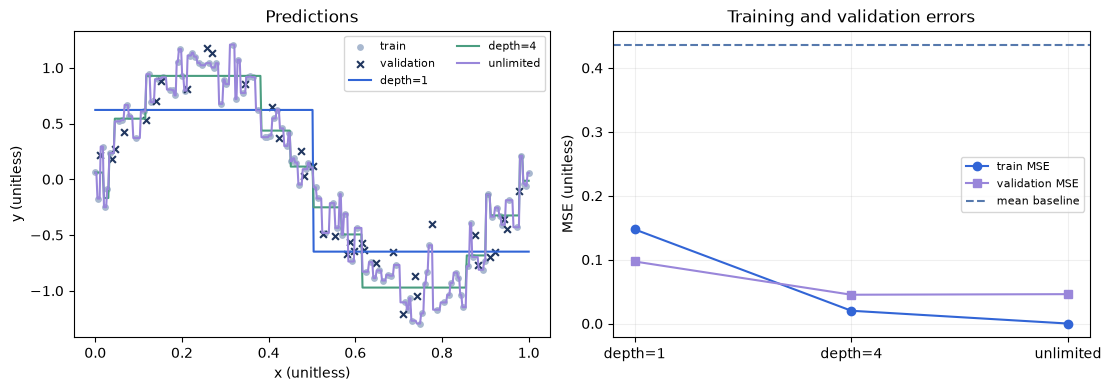

In [6]:
import matplotlib.pyplot as plt

# 横轴 x 无单位，预测曲线只用于查看形状，不参与超参数选择。
grid = np.linspace(0, 1, 400).reshape(-1, 1)
names = ["depth=1", "depth=4", "unlimited"]
colors = ["#3265D6", "#4A9D80", "#9986DA"]
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), constrained_layout=True)
axes[0].scatter(Xw_train[:, 0], yw_train, s=15, color="#A8B8CF", label="train")
axes[0].scatter(Xw_val[:, 0], yw_val, s=24, marker="x", color="#20365F", label="validation")
for model, name, color in zip(models, names, colors):
    axes[0].plot(grid[:, 0], model.predict(grid), color=color, label=name)
axes[0].set(xlabel="x (unitless)", ylabel="y (unitless)", title="Predictions")
axes[0].legend(fontsize=8, ncol=2)

# 折线比较三个离散候选；虚线是同一验证集上的均值基线。
axes[1].plot(names, errs[:, 0], "o-", color="#3265D6", label="train MSE")
axes[1].plot(names, errs[:, 1], "s-", color="#9986DA", label="validation MSE")
axes[1].axhline(base_mse, color="#5679AD", linestyle="--", label="mean baseline")
axes[1].set(ylabel="MSE (unitless)", title="Training and validation errors")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.2)

# 预期：左图包含训练/验证点和三条预测线；右图可见训练误差与验证误差的差距。
# 重点对照无限制树的训练误差和验证误差，不能仅凭更低的训练误差选模型。
plt.show()

## 6 固定选择，再作一次最终测试

本实验的规则事先确定为“在三个候选中选择验证 MSE 最小者”。设置选定后，用训练与验证合并的开发集重新拟合，再使用一直保留的测试集评估；均值基线也在相同开发集上拟合，以保持比较条件一致。

测试分数用于报告当前流程在保留样本上的表现。本节之后不再根据测试结果更换深度、指标或随机种子；反复据此修改，相当于把测试集变成了新的验证集。单次小样本保留集结果存在抽样波动，更多数据或独立重复实验仍有价值。

In [7]:
# 只看验证误差列选设置；不读取测试标签来选择深度。
best = int(np.argmin(errs[:, 1]))
final = DecisionTreeRegressor(max_depth=depths[best], random_state=42)
final.fit(Xw_dev, yw_dev)
final_base = DummyRegressor(strategy="mean")
final_base.fit(Xw_dev, yw_dev)

# 到这里才预测和评估合成曲线实验的最终测试集。
test_mse = np.mean((yw_test - final.predict(Xw_test)) ** 2)
test_base_mse = np.mean((yw_test - final_base.predict(Xw_test)) ** 2)
# 预期：选中前面验证 MSE 最小的候选，打印两个非负测试误差；不预设跨数据排名。
print("验证集选择：", names[best])
print(f"最终测试 MSE：模型={test_mse:.4f}，均值基线={test_base_mse:.4f}")

验证集选择： depth=4
最终测试 MSE：模型=0.0470，均值基线=0.6401


## 7 重复实体应按预测目标分组

假设每位用户有多次观测，目标是预测从未出现过的新用户。若把行随机分开，同一用户可能同时进入训练与验证，得到的结果不能回答“对新用户有效吗”。应以用户标识分组，把一个用户的全部记录放在同一侧。

下面只观察划分索引，不训练模型。groups 中相同的整数代表同一用户；GroupShuffleSplit 的 test\_size 指组数比例，不是行数比例。在开发阶段，它返回的第二组索引用作验证集；参数名中的 test 不代表必须用于最终测试。它本身不保证类别分层；同时存在时间关系时还需满足预测时点的约束。

In [8]:
from sklearn.model_selection import GroupShuffleSplit

# 6 位合成用户各有 3 条记录；Xg 中的数值只是用于观察行号。
groups = np.repeat(np.arange(6), 3)
Xg = np.arange(18).reshape(-1, 1)
row_train, row_val = train_test_split(np.arange(18), test_size=1 / 3, random_state=42)
# 反例：只按行随机切分，检查同一用户是否跨越两份数据。
overlap = np.intersect1d(groups[row_train], groups[row_val])
# 预期：本次会列出非空的重叠用户编号，提示该划分不能评估全新用户。
print("按行划分的重叠用户：", overlap)

# 按用户抽取一次划分；next 取出 split 产生的第一对索引。
split = GroupShuffleSplit(n_splits=1, test_size=1 / 3, random_state=42)
group_train, group_val = next(split.split(Xg, groups=groups))
overlap = np.intersect1d(groups[group_train], groups[group_val])
# 预期：训练包含 4 位用户、验证包含 2 位用户，二者交集为空数组 []。
print("训练用户：", np.unique(groups[group_train]))
print("验证用户：", np.unique(groups[group_val]))
print("分组后的重叠用户：", overlap)

按行划分的重叠用户： [0 1 2 4]
训练用户： [2 3 4 5]
验证用户： [0 1]
分组后的重叠用户： []


## 8 预测未来时保留时间顺序

用过去预测未来时，训练数据必须早于要评估的数据。先按预测时点排序，再取连续时间段；随机打乱会让未来信息进入训练。这里的 day 是 0 到 11 的等间隔观测日期编号，每个编号对应一天，已按时间升序排列。

先把最后两天留作最终测试，开发阶段不使用它们。TimeSeriesSplit 演示在开发数据中逐步扩大训练窗口、用后续时段验证；这里设置两次划分，每次验证两天。gap=1 在训练末端和验证起点之间留出一条观测的间隔。gap 只按行数跳过样本，不会自动识别标签延迟或特征中隐藏的未来信息；实际间隔要按预测与标签生成过程选择。

TimeSeriesSplit 要求先自行排好时间顺序；若要让各折覆盖相同时间长度，样本还需等间隔。下面只查看日期边界，不把各折指标称作独立最终测试结果。

In [9]:
from sklearn.model_selection import TimeSeriesSplit

day = np.arange(12)
day_dev, day_test = day[:10], day[10:]
# 预期：开发期最后一天是 9，最终测试期是 [10 11]。
print("开发期末尾与保留测试期：", day_dev[-1], day_test)

split = TimeSeriesSplit(n_splits=2, test_size=2, gap=1)
for fold, (past, future) in enumerate(split.split(day_dev), start=1):
    # 预期：两次训练终点为第 4、6 天，验证时段为 [6 7]、[8 9]。
    # 中间各空出一天；训练最大日期始终小于验证最小日期。
    print(f"划分 {fold}：训练 {day_dev[past]}，验证 {day_dev[future]}")

开发期末尾与保留测试期： 9 [10 11]
划分 1：训练 [0 1 2 3 4]，验证 [6 7]
划分 2：训练 [0 1 2 3 4 5 6]，验证 [8 9]


## 9 先划分，再学习预处理参数

数据泄漏（data leakage）是构建模型时用了预测场景下本不应获得的信息。即使不读取标签，用全部数据学习均值、缩放尺度或缺失值填充值，也会使保留数据影响训练流程。

下面只做“减去训练均值”，不讨论完整的缩放算法。设训练特征均值为 $\mu$，对任一输入 $x$ 使用相同的变换 $z=x-\mu$。fit 学习 $\mu$，transform 应用已学参数；StandardScaler(with\_std=False) 实现这种仅中心化的变换。

本例预先给定训练值 $[0,2]$ 和验证值 $[10,12]$。训练均值为 1；若错误地先合并再 fit，会用到均值 6。验证结果不需要均值为 0，也不能为追求均值为 0 而在验证集上重新拟合。两边必须沿用训练时学到的同一个变换。

In [10]:
from sklearn.preprocessing import StandardScaler

Xs_train = np.array([[0.0], [2.0]])
Xs_val = np.array([[10.0], [12.0]])

# 正常流程：训练均值由训练数据拟合，验证数据只接受变换。
scaler = StandardScaler(with_std=False)
scaler.fit(Xs_train)
train_centered = scaler.transform(Xs_train)
val_centered = scaler.transform(Xs_val)
# 预期：均值 [1.]；训练变成 [-1. 1.]，验证变成 [9. 11.]。
print("训练学到的均值：", scaler.mean_)
print("训练、验证变换：", train_centered.ravel(), val_centered.ravel())

# 反例：仅为展示泄漏，不把这个对象用于任何正式评估。
leaked = StandardScaler(with_std=False)
leaked.fit(np.vstack([Xs_train, Xs_val]))
# 预期：均值变成 [6.]；验证信息已影响参数，即使代码没有读取标签。
print("错误合并后学到的均值：", leaked.mean_)

训练学到的均值： [1.]
训练、验证变换： [-1.  1.] [ 9. 11.]
错误合并后学到的均值： [6.]


## 10 检查特征在预测时是否真实可用

正确划分仍不能补救带有答案的输入。假设要在下单时预测未来是否退货：下单金额和此前订单数在当时可获得，而退货后的处理结果不可获得。把后者当特征，等于把结果提前告诉模型，属于标签泄漏。

下面用极端反例展示问题：事后字段直接编码了“是否发生退货”。即使训练与验证行完全分开，也可以从该字段读出答案；高准确率在这里不能证明预测能力。字段是否可用由真实生成时点决定，不能靠修改字段名、随机划分或 Pipeline 自动判断。

In [11]:
# 4 笔合成订单：0 表示未退货，1 表示退货；字段顺序与目标逐行对应。
amount = np.array([40.0, 80.0, 60.0, 100.0])
prior_orders = np.array([2, 0, 3, 1])
returned = np.array([0, 1, 0, 1])
after_return = np.array([0, 1, 0, 1])

# 下单时可用的输入只包含金额和此前订单数。
X_at_order = np.column_stack([amount, prior_orders])
# 预期：(4, 2)，只保留两列在预测时点已存在的输入。
print("下单时可用的特征形状：", X_at_order.shape)

# 反例：直接用事后字段当预测。这是读取答案，不是可部署的预测方法。
bad_pred = after_return
# 预期：1.0；这个完美分数来自标签泄漏，不能用于证明模型有效。
print("泄漏字段得到的准确率：", np.mean(returned == bad_pred))

下单时可用的特征形状： (4, 2)
泄漏字段得到的准确率： 1.0


## 本章小结

（1）训练集学习参数，验证集选择设置，测试集在开发流程固定后作最终评估。训练误差小不等于泛化好。

（2）均值是等权平方误差下的最佳常数预测，多数类是训练错误率下的最佳固定类别；比较时使用同一划分和指标，不能把基线当作成绩下限。

（3）样本关系决定划分方式：独立样本可随机划分，分类按需分层；评估新实体要分组，预测未来要保持时间方向。

（4）先划分再拟合预处理，保留数据只做变换；还需逐项确认特征的生成时点。能运行和分数高都不能替代这两类检查。

自查：为什么训练均值不能替换成验证均值？为什么“随机种子固定”不能证明没有泄漏？如果测试集参与了反复选参数，它还承担什么角色？

## 练习

（1）预测多数类基线的表现。训练标签改为 8 个 0、2 个 1，验证标签改为 $[0,1,1,1]$。先写出多数类及两份准确率，再运行下方代码核对。解释为什么只看训练准确率会误判。

（2）把第 7 节的用户记录数改为 $[1,2,3,4,5,6]$，保持 6 位用户和 test\_size=1/3。检查训练与验证用户交集仍为空，并说明为什么验证行数未必占总行数的 1/3；不要根据验证分数反复挑选种子。

（3）要在每日 0 点预测当天是否退货，候选字段为“昨日累计订单数”“当日结束后更新的退货次数”。说明哪个字段可用，以及应该随机划分还是按时间划分。可验证标准：每个保留样本的预测时点，训练所用记录及输入字段都已经可获得。

In [12]:
# 先写下你的预测，再执行；这里复用本章导入的 np 和 DummyClassifier。
ex_train = np.array([0] * 8 + [1] * 2)
ex_val = np.array([0, 1, 1, 1])
labels, counts = np.unique(ex_train, return_counts=True)
ex_major = labels[np.argmax(counts)]
ex_pred = np.full(len(ex_val), ex_major)

# 运行后核对：类别是否取自训练集，两份准确率是否符合各自的类别比例。
# 这是预测练习，先不要查看后面的解析。
print("训练多数类：", ex_major)
print("训练、验证准确率：", np.mean(ex_train == ex_major), np.mean(ex_val == ex_pred))

训练多数类： 0
训练、验证准确率： 0.8 0.25


### 重点题提示与解析

第（1）题提示：固定预测一个类别时，只需要数这类在每份数据里占多少。解析：训练多数类是 0，训练准确率 $8/10=0.8$，验证准确率 $1/4=0.25$。模型没有学习特征关系，类别分布变化会直接改变分数；不要用验证多数类重新拟合来“修复”成绩。

第（2）题提示：先按 groups 统计不同用户，再统计各用户对应的行数。解析：test\_size 控制选择 2 位用户，但不同用户拥有的记录数不同，因此两位用户对应的行数比例不固定。判断核心仍是实体是否跨越边界；部署目标若变为“老用户的未来记录”，还须改用与该目标一致的时间设计。

第（3）题提示：把预测时刻标在时间线上，检查字段生成时刻位于哪一侧。解析：“昨日累计订单数”在每日 0 点可用；“当日结束后更新的退货次数”包含未来信息，必须移除或改为预测前已知的历史统计。保留较晚时段作验证与测试，涉及延迟标签时还要检查训练标签在每个预测时刻是否已可获得。

## 参考与引用来源

以下为写作时核查的第一方来源，其中 scikit-learn 文档为 1.9.1。示例数据、代码和流程示意图由本项目编写；均值基线的推导是最小二乘常数模型的特例，多数类推导是等权分类错误率在固定类别模型上的特例。环境实际验证版本见课程 README。

| 网站 | 页面、定位与支持内容 |
| --- | --- |
| scikit-learn 官方文档 | [Cross-validation](https://scikit-learn.org/stable/modules/cross_validation.html)：开篇训练／验证／测试边界、Data transformation with held-out data、Stratification、Grouped data、Time series；[train\_test\_split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)：test\_size、random\_state、stratify；[GroupShuffleSplit](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GroupShuffleSplit.html)：test\_size 以组计数；[TimeSeriesSplit](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html)：时间顺序、等间隔条件、gap。[DummyRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyRegressor.html) 的 mean、[DummyClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyClassifier.html) 的 most\_frequent；[Metrics and scoring](https://scikit-learn.org/stable/modules/model_evaluation.html)：Accuracy score、Mean squared error 与预测统计量／损失的对应关系。[Underfitting vs. Overfitting](https://scikit-learn.org/stable/auto_examples/model_selection/plot_underfitting_overfitting.html)：复杂度与保留数据误差；[DecisionTreeRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html)：max\_depth、fit、predict。[Common pitfalls](https://scikit-learn.org/stable/common_pitfalls.html)：Data leakage、How to avoid data leakage、Controlling randomness；[StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)：with\_std=False、mean\_、fit 与 transform。 |
| Stanford CS229 官方讲义 | Tengyu Ma、Andrew Ng，[CS229 Lecture Notes](https://cs229.stanford.edu/main_notes.pdf)，2026-08-23 版：§1.1 与 §1.2.2，印刷页 10—16，最小二乘目标与求导求解；§8.3.1，印刷页 129—130，训练分类错误率与泛化错误的区别；§9.3，印刷页 142—144，保留集模型选择。本章只使用相应基础概念与常数模型特例，不展开学习理论界。 |
| NumPy 官方文档 | [numpy.unique](https://numpy.org/doc/stable/reference/generated/numpy.unique.html)：类别与计数；[numpy.argmax](https://numpy.org/doc/stable/reference/generated/numpy.argmax.html)：最大值索引；[numpy.random.default_rng](https://numpy.org/doc/stable/reference/random/generator.html)：显式种子的 Generator 及合成数据生成。 |
| Matplotlib 官方文档 | [pyplot.subplots](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots.html)、[Axes.plot](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.plot.html)、[Axes.scatter](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.scatter.html)、[pyplot.show](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.show.html)：并排子图、预测曲线、样本散点及显式展示。 |